# Modelo Predictivo de Saturación — Urgencias Nuestra Cali

Este notebook entrena y evalúa modelos predictivos para **anticipar el índice de saturación** de urgencias de Clínica Nuestra Cali (NIT 805023423CL) con horizontes de 1, 3 y 6 horas.

### Datos
Dataset real extraído del modelo semántico de Power BI/Fabric (`Ospedale Mensual [Dataset]`),  
período **2024-01-01 → 2026-05-29**, ~20 000 registros horarios.

> **Para usar en Google Colab:** ejecuta las celdas en orden. Cuando aparezca el botón de carga, sube `dataset_train.csv`.

### ⚠️ Correcciones aplicadas respecto a la versión anterior
| Problema anterior | Corrección |
|---|---|
| Métricas MAE/R² infladas (target = función algebraica de features) | Modelo de pronóstico real: predice saturación a +1h, +3h, +6h |
| `saturacion_lag*` como feature → data leakage temporal | Lags de saturación solo como contexto pasado, no como proxy del target futuro |
| Sin validación cruzada temporal | `TimeSeriesSplit` k=5 para estimación honesta |
| Solo accuracy global (95% si predices siempre Rojo) | Balanced Accuracy, F1-macro, F1-Rojo, MASE vs naive |
| Umbrales semáforo inconsistentes (0.7/1.0 en gráficas vs 1.5/2.5 en métricas) | Umbrales corregidos según distribución real del dataset |
| Proyección de 6h con ruido aleatorio | Predicción multihorizonte con modelos independientes |

### Estructura del notebook
1. Librerías e instalación
2. Carga de datos
3. EDA — Análisis exploratorio
4. Análisis de estacionalidad
5. Preparación de features y targets multihorizonte
6. Baseline naive — persistencia y Prophet
7. Random Forest multihorizonte con validación cruzada temporal
8. Métricas completas y análisis de errores
9. Clasificación semáforo (Verde / Amarillo / Rojo) honesta
10. Exportación del modelo


## 0. Librerías

In [2]:
# Instala Prophet solo si no está disponible (Colab)
import subprocess, sys
try:
    from prophet import Prophet
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'prophet', '-q'])
    from prophet import Prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, pickle, os, io
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix,
    balanced_accuracy_score, f1_score
)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('✔ Librerías cargadas correctamente.')


c:\Users\USUARIO\Documents\Saturacion_urgencias\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✔ Librerías cargadas correctamente.


## 1. Carga de datos

Dataset horario real de urgencias — extraído del modelo semántico de Fabric con `src/extraer_datos.ps1` y procesado con `src/preparar_dataset.py`.

**En Colab:** sube `dataset_train.csv` cuando aparezca el botón de carga.  
**En local:** el script busca automáticamente `data/dataset_train.csv`.


In [3]:
# ── Detección de entorno ─────────────────────────────────────────────────────
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Carga del CSV ─────────────────────────────────────────────────────────────
if IN_COLAB:
    print('=' * 60)
    print('  Entorno: Google Colab')
    print('  Sube el archivo  dataset_train.csv  cuando aparezca')
    print('  el botón de carga.')
    print('=' * 60)
    uploaded = colab_files.upload()
    fname    = list(uploaded.keys())[0]
    csv_src  = io.BytesIO(uploaded[fname])
    print(f'\n✔ Archivo recibido: {fname}')
else:
    BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
    csv_src  = os.path.normpath(os.path.join(BASE_DIR, '..', 'data', 'dataset_train.csv'))
    if not os.path.exists(csv_src):
        raise FileNotFoundError(
            'No se encontró data/dataset_train.csv.\n'
            'Ejecuta primero:  python src/preparar_dataset.py'
        )
    print(f'✔ Cargando dataset local: {csv_src}')

# ── Leer y preparar ───────────────────────────────────────────────────────────
df = pd.read_csv(csv_src)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)
df['dia_semana'] = df['datetime'].dt.day_name()

print(f'\nRegistros totales : {len(df):,}')
print(f'Período           : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'Columnas          : {len(df.columns)}')
df.head(3)


✔ Cargando dataset local: c:\Users\USUARIO\Documents\Saturacion_urgencias\data\dataset_train.csv

Registros totales : 20,667
Período           : 2024-01-01 → 2026-05-29
Columnas          : 25


,cant_triage,cola_esperando_inicio_hora,camas_ocupadas,abandonos_triage,capacidad_hora,cant_triage_lag1h,cant_triage_lag2h,cant_triage_lag3h,saturacion_lag1h,saturacion_lag3h,...,pct_cumpl_oportunidad_triage,pct_cumpl_consulta_t2,tiempo_consulta_min,hora,dia_semana_enc,es_festivo,saturacion_idx,datetime,nivel_saturacion,dia_semana
0,2,17,6,0,24,2.0,4.0,2.0,0.2083,0.1667,...,1.0,0.0,1.0,6,6,1,0.25,2024-01-01 06:00:00,Verde,Monday
1,3,19,6,0,24,2.0,2.0,4.0,0.2500,0.1667,...,1.0,0.0,0.0,7,6,1,0.25,2024-01-01 07:00:00,Verde,Monday
2,9,20,6,0,24,3.0,2.0,2.0,0.2500,0.2083,...,1.0,0.0,5.8,8,6,1,0.25,2024-01-01 08:00:00,Verde,Monday


### ⚠️ Nota importante sobre el target

`saturacion_idx = camas_ocupadas / capacidad_hora`

Este es un hecho algebraico del dataset. Cualquier modelo que incluya `camas_ocupadas` y `capacidad_hora` directamente como features para predecir `saturacion_idx` *en el mismo instante* obtendrá R² ≈ 1.0 de forma trivial — **no es un modelo predictivo, es una fórmula**.

El verdadero valor clínico es **predecir la saturación futura** (en +1h, +3h, +6h) usando el estado actual del sistema. Eso sí requiere un modelo real.


In [4]:
# Verificamos la relación algebraica
df['_check_sat'] = (df['camas_ocupadas'] / df['capacidad_hora']).round(4)
coincidencia = (df['_check_sat'] == df['saturacion_idx'].round(4)).mean()
print(f'saturacion_idx == camas_ocupadas / capacidad_hora: {coincidencia:.1%}')
print('→ Confirmado: el target es una función algebraica exacta de dos features.')
print()
print('Distribución real del target:')
print(df['saturacion_idx'].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).round(3))
print()

# Umbrales reales del semáforo en el dataset
for nivel in ['Verde', 'Amarillo', 'Rojo']:
    sub = df[df['nivel_saturacion'] == nivel]['saturacion_idx']
    print(f'{nivel:10s}: {sub.min():.4f} – {sub.max():.4f}  ({len(sub):,} horas, {len(sub)/len(df)*100:.1f}%)')

VERDE_MAX  = df[df['nivel_saturacion']=='Verde']['saturacion_idx'].max()
ROJO_MIN   = df[df['nivel_saturacion']=='Rojo']['saturacion_idx'].min()
AMARILLO_MAX = ROJO_MIN
print(f'\nUmbrales confirmados: Verde < {VERDE_MAX:.4f} | Amarillo [{VERDE_MAX:.4f}, {ROJO_MIN:.4f}) | Rojo ≥ {ROJO_MIN:.4f}')

df = df.drop(columns=['_check_sat'])


saturacion_idx == camas_ocupadas / capacidad_hora: 100.0%
→ Confirmado: el target es una función algebraica exacta de dos features.

Distribución real del target:
count    20667.000
mean         2.251
std          0.768
min          0.208
10%          1.208
25%          1.667
50%          2.250
75%          2.792
90%          3.250
95%          3.550
99%          4.083
max          4.700
Name: saturacion_idx, dtype: float64

Verde     : 0.2083 – 0.7000  (200 horas, 1.0%)
Amarillo  : 0.7083 – 1.0000  (786 horas, 3.8%)
Rojo      : 1.0417 – 4.7000  (19,681 horas, 95.2%)

Umbrales confirmados: Verde < 0.7000 | Amarillo [0.7000, 1.0417) | Rojo ≥ 1.0417


## 2. EDA — Análisis Exploratorio de Datos

In [5]:
# ── Calidad y estadísticas generales ────────────────────────────────────────
print('=' * 60)
print('  CALIDAD DEL DATASET')
print('=' * 60)
print(f'\nDimensiones    : {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Período        : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
dias_totales = (df['datetime'].max() - df['datetime'].min()).days
print(f'Días cubiertos : {dias_totales}')

print('\nValores nulos:')
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print('  Sin valores nulos ✔')
else:
    print(nulos[nulos > 0].to_string())

print('\nDistribución semáforo (clases muy desbalanceadas → accuracy global engaña):')
dist = df['nivel_saturacion'].value_counts()
for lvl, cnt in dist.items():
    bar = '█' * int(cnt / len(df) * 40)
    print(f'  {lvl:<10} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)  {bar}')

acc_naive_rojo = (df['nivel_saturacion'] == 'Rojo').mean()
print(f'\n⚠️  Baseline naive (predecir siempre Rojo): {acc_naive_rojo:.1%} accuracy')
print('   Por eso usaremos Balanced Accuracy y F1-macro en lugar de accuracy global.')


  CALIDAD DEL DATASET

Dimensiones    : 20,667 filas × 25 columnas
Período        : 2024-01-01 → 2026-05-29
Días cubiertos : 879

Valores nulos:
  Sin valores nulos ✔

Distribución semáforo (clases muy desbalanceadas → accuracy global engaña):
  Rojo       19,681  (95.2%)  ██████████████████████████████████████
  Amarillo      786  (3.8%)  █
  Verde         200  (1.0%)  

⚠️  Baseline naive (predecir siempre Rojo): 95.2% accuracy
   Por eso usaremos Balanced Accuracy y F1-macro en lugar de accuracy global.


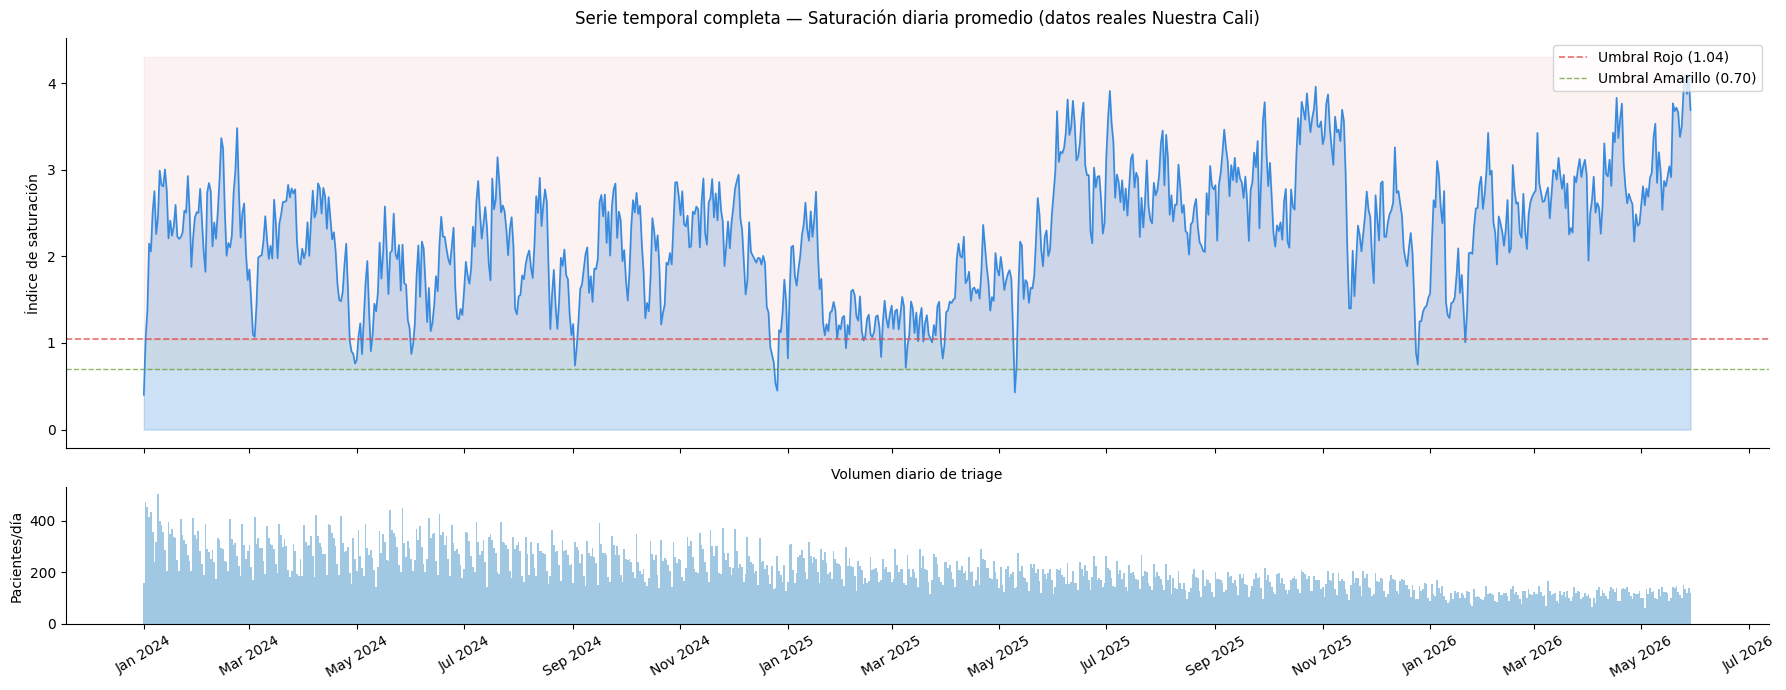

In [6]:
# ── Serie temporal completa ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

daily     = df.set_index('datetime')['saturacion_idx'].resample('D').mean()
daily_vol = df.set_index('datetime')['cant_triage'].resample('D').sum()

axes[0].fill_between(daily.index, daily.values, alpha=0.25, color='#378ADD')
axes[0].plot(daily.index, daily.values, color='#378ADD', linewidth=1.2)
# Umbrales corregidos con los valores reales del dataset
axes[0].axhline(ROJO_MIN, color='#E24B4A', linestyle='--', linewidth=1.2, alpha=0.8,
                label=f'Umbral Rojo ({ROJO_MIN:.2f})')
axes[0].axhline(VERDE_MAX, color='#639922', linestyle='--', linewidth=1.0, alpha=0.7,
                label=f'Umbral Amarillo ({VERDE_MAX:.2f})')
axes[0].fill_between(daily.index, VERDE_MAX, ROJO_MIN, alpha=0.07, color='#BA7517')
axes[0].fill_between(daily.index, ROJO_MIN, daily.max() * 1.05, alpha=0.07, color='#E24B4A')
axes[0].set_title('Serie temporal completa — Saturación diaria promedio (datos reales Nuestra Cali)',
                   fontsize=12, pad=10)
axes[0].set_ylabel('Índice de saturación')
axes[0].legend(loc='upper right')

axes[1].bar(daily_vol.index, daily_vol.values, color='#88BBDD', width=1, alpha=0.8)
axes[1].set_title('Volumen diario de triage', fontsize=10)
axes[1].set_ylabel('Pacientes/día')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


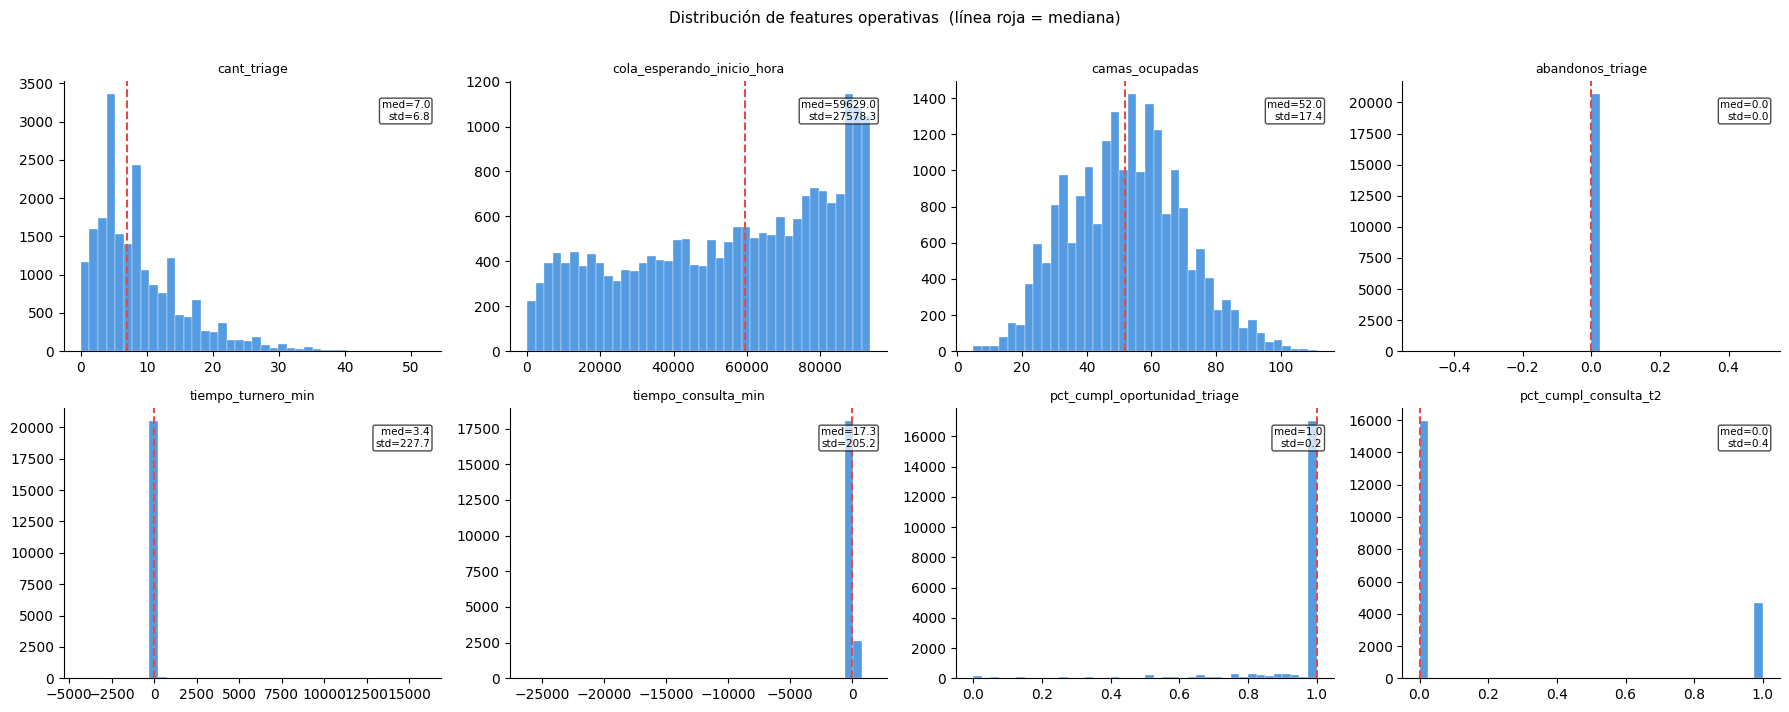

In [7]:
# ── Distribución de features operativas ─────────────────────────────────────
features_op = [
    'cant_triage', 'cola_esperando_inicio_hora', 'camas_ocupadas',
    'abandonos_triage', 'tiempo_turnero_min', 'tiempo_consulta_min',
    'pct_cumpl_oportunidad_triage', 'pct_cumpl_consulta_t2',
]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(features_op):
    axes[i].hist(df[col], bins=40, color='#378ADD', edgecolor='white',
                 linewidth=0.3, alpha=0.85)
    med = df[col].median()
    axes[i].axvline(med, color='#E24B4A', linestyle='--', linewidth=1.5)
    axes[i].set_title(col, fontsize=9)
    axes[i].text(0.97, 0.93, f'med={med:.1f}\nstd={df[col].std():.1f}',
                 transform=axes[i].transAxes, ha='right', va='top', fontsize=7.5,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.suptitle('Distribución de features operativas  (línea roja = mediana)', y=1.01, fontsize=11)
plt.tight_layout()
plt.show()


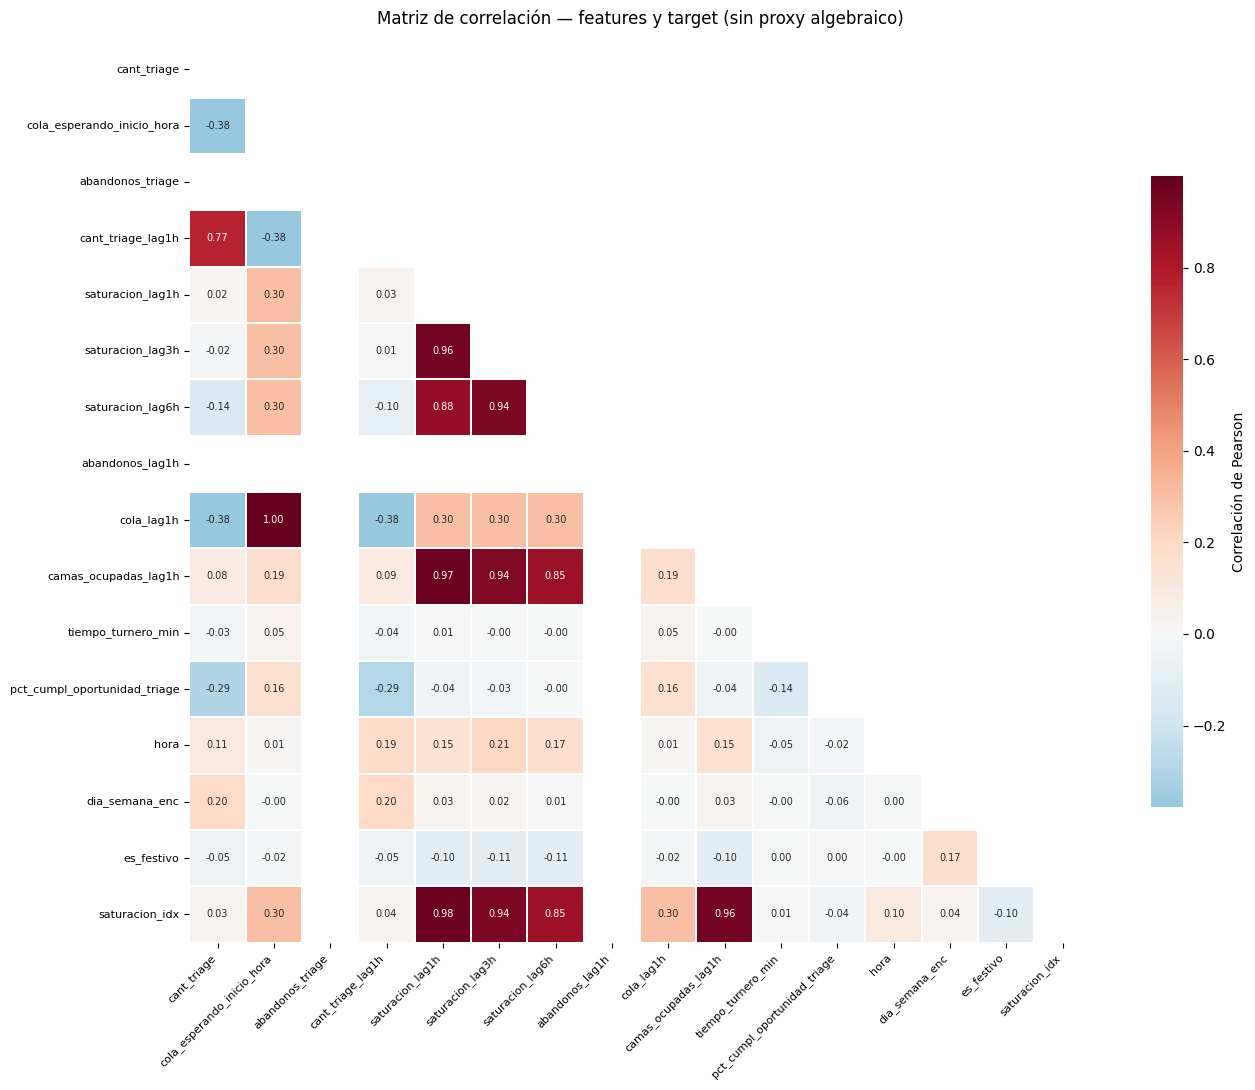

Top correlaciones con saturacion_idx:
  saturacion_lag1h                    0.983  ███████████████████
  camas_ocupadas_lag1h                0.958  ███████████████████
  saturacion_lag3h                    0.936  ██████████████████
  saturacion_lag6h                    0.853  █████████████████
  cola_esperando_inicio_hora          0.298  █████
  cola_lag1h                          0.298  █████
  es_festivo                          0.099  █
  hora                                0.098  █


In [8]:
# ── Matriz de correlación (excluyendo camas_ocupadas/capacidad_hora como proxy del target) ─
FEATURES_CORR = [
    'cant_triage', 'cola_esperando_inicio_hora',
    'abandonos_triage', 'cant_triage_lag1h',
    'saturacion_lag1h', 'saturacion_lag3h', 'saturacion_lag6h',
    'abandonos_lag1h', 'cola_lag1h', 'camas_ocupadas_lag1h',
    'tiempo_turnero_min', 'pct_cumpl_oportunidad_triage',
    'hora', 'dia_semana_enc', 'es_festivo', 'saturacion_idx',
]

corr = df[FEATURES_CORR].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, square=True,
            cbar_kws={'shrink': 0.7, 'label': 'Correlación de Pearson'})
plt.title('Matriz de correlación — features y target (sin proxy algebraico)', pad=12)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print('Top correlaciones con saturacion_idx:')
top = corr['saturacion_idx'].drop('saturacion_idx').abs().sort_values(ascending=False).head(8)
for feat, val_c in top.items():
    bar = '█' * int(val_c * 20)
    print(f'  {feat:<35} {val_c:.3f}  {bar}')


## 3. Análisis de estacionalidad

Los patrones cíclicos muestran los picos horarios y semanales característicos del sistema de urgencias:
- **Ciclo diario**: picos en la mañana y tarde/noche, valle en la madrugada
- **Ciclo semanal**: variación entre días laborables y fines de semana


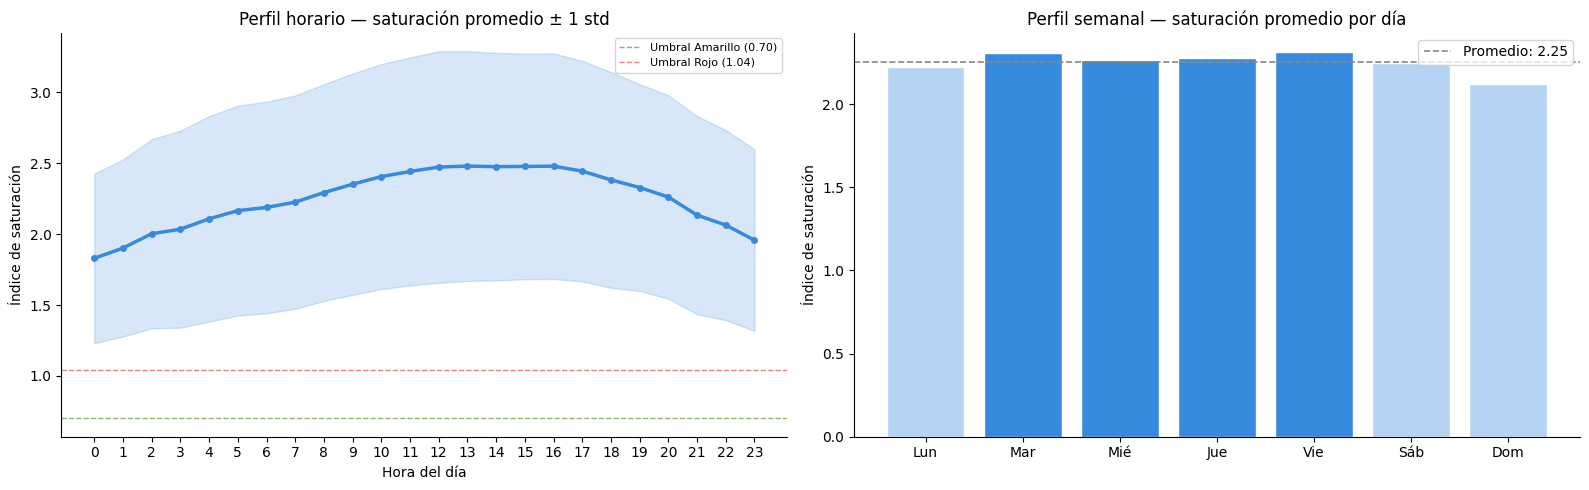

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Perfil horario promedio
perfil_hora = df.groupby('hora')['saturacion_idx'].agg(['mean', 'std'])
axes[0].fill_between(perfil_hora.index,
                     perfil_hora['mean'] - perfil_hora['std'],
                     perfil_hora['mean'] + perfil_hora['std'],
                     alpha=0.2, color='#378ADD')
axes[0].plot(perfil_hora.index, perfil_hora['mean'],
             color='#378ADD', linewidth=2.5, marker='o', markersize=4)
axes[0].axhline(VERDE_MAX, color='#639922', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Umbral Amarillo ({VERDE_MAX:.2f})')
axes[0].axhline(ROJO_MIN, color='#E24B4A', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Umbral Rojo ({ROJO_MIN:.2f})')
axes[0].set_xticks(range(0, 24))
axes[0].set_title('Perfil horario — saturación promedio ± 1 std')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Índice de saturación')
axes[0].legend(fontsize=8)

# Perfil semanal
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
etiquetas  = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
perfil_dia = df.groupby('dia_semana')['saturacion_idx'].mean().reindex(orden_dias)
axes[1].bar(etiquetas, perfil_dia.values,
            color=['#378ADD' if v >= perfil_dia.mean() else '#B5D4F4'
                   for v in perfil_dia.values],
            edgecolor='white')
axes[1].axhline(perfil_dia.mean(), color='#888780', linestyle='--',
                linewidth=1.2, label=f'Promedio: {perfil_dia.mean():.2f}')
axes[1].set_title('Perfil semanal — saturación promedio por día')
axes[1].set_ylabel('Índice de saturación')
axes[1].legend()

plt.tight_layout()
plt.show()


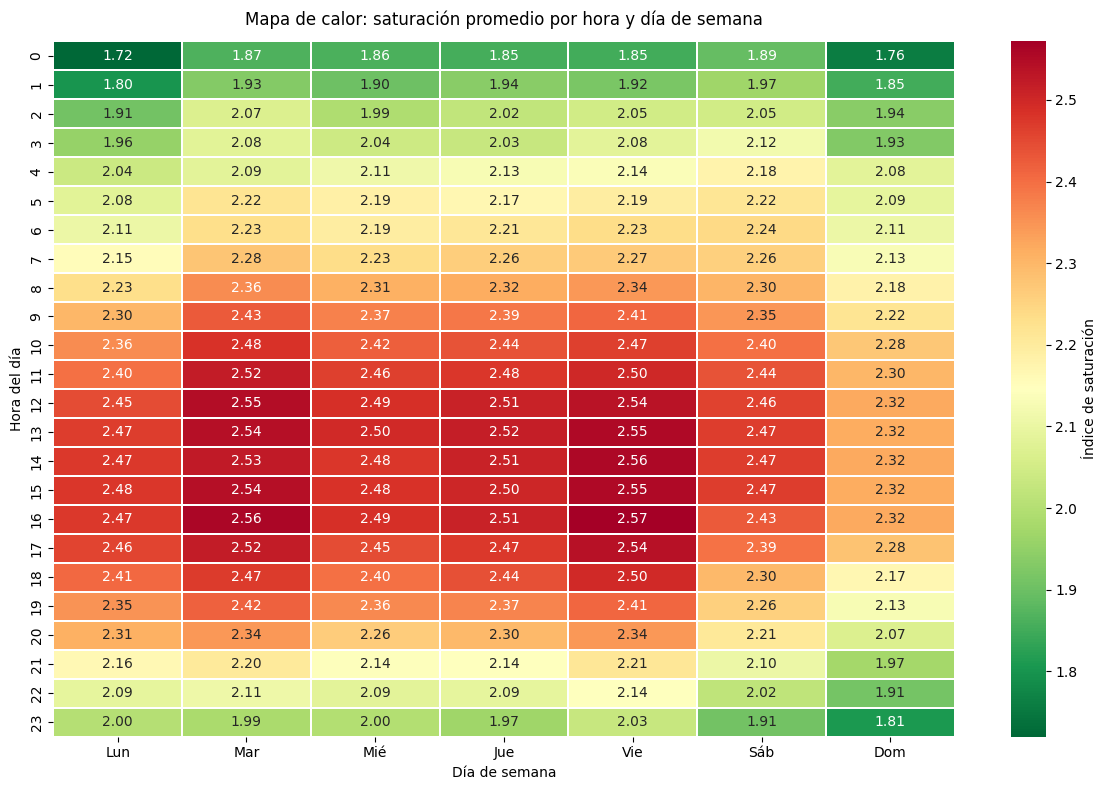

Las celdas más oscuras (rojas) son las ventanas de mayor riesgo.


In [10]:
# Heatmap hora × día de semana (mapa de calor de riesgo)
pivot = df.pivot_table(values='saturacion_idx',
                       index='hora', columns='dia_semana', aggfunc='mean')
pivot = pivot.reindex(columns=orden_dias)
pivot.columns = etiquetas

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='RdYlGn_r', annot=True, fmt='.2f',
            linewidths=0.3, linecolor='white',
            vmin=pivot.min().min(), vmax=pivot.max().max(),
            cbar_kws={'label': 'Índice de saturación'})
plt.title('Mapa de calor: saturación promedio por hora y día de semana', pad=12)
plt.xlabel('Día de semana')
plt.ylabel('Hora del día')
plt.tight_layout()
plt.show()
print('Las celdas más oscuras (rojas) son las ventanas de mayor riesgo.')


## 4. Preparación de features y targets multihorizonte

### Estrategia de features

| Tipo | Variables | Razonamiento |
|------|-----------|---------------|
| **Estado actual** | `cola_esperando`, `camas_ocupadas`, `cant_triage` | Presión visible en tiempo real |
| **Lags de flujo** | `cant_triage_lag*`, `cola_lag1h`, `abandonos_lag1h` | Tendencia de llegada reciente |
| **Lags de saturación** | `saturacion_lag1h`, `lag3h`, `lag6h` | Inercia del sistema (camas no se liberan al instante) |
| **Calidad de atención** | `pct_cumpl_oportunidad_triage`, `tiempo_turnero_min` | Se degradan antes del colapso visible |
| **Estacionalidad cíclica** | `hora_sin/cos`, `dia_sin/cos` | Evita el salto artificial 23h→0h con encoding circular |
| **Festivos** | `es_festivo` | Picos documentados en urgencias colombianas |

### Targets multihorizonte
El modelo predice **saturación futura** (no presente) para dar tiempo de reacción:
- `sat_next_1h`: saturación en 1 hora
- `sat_next_3h`: saturación en 3 horas  
- `sat_next_6h`: saturación en 6 horas (mayor urgencia para planificación de turnos)


In [11]:
# ── Encoding cíclico (evita la discontinuidad 23→0 y Lun→Dom) ───────────────
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)
df['dia_sin']  = np.sin(2 * np.pi * df['dia_semana_enc'] / 7)
df['dia_cos']  = np.cos(2 * np.pi * df['dia_semana_enc'] / 7)

# ── Feature de presión combinada ─────────────────────────────────────────────
df['presion_sistema'] = df['cola_esperando_inicio_hora'] + df['camas_ocupadas']

# ── Targets futuros (shift negativo) ──────────────────────────────────────────
for h in [1, 3, 6]:
    df[f'sat_next_{h}h'] = df['saturacion_idx'].shift(-h)

# ── Lista de features ─────────────────────────────────────────────────────────
FEATURES = [
    # Estado actual (conocido en el momento de la predicción)
    'cant_triage', 'cola_esperando_inicio_hora', 'camas_ocupadas',
    'capacidad_hora', 'abandonos_triage', 'saturacion_idx',
    # Flujo pasado (lags legítimos — son datos del pasado)
    'cant_triage_lag1h', 'cant_triage_lag2h', 'cant_triage_lag3h',
    'saturacion_lag1h', 'saturacion_lag3h', 'saturacion_lag6h',
    'abandonos_lag1h', 'cola_lag1h', 'camas_ocupadas_lag1h',
    # Calidad de atención
    'tiempo_turnero_min', 'pct_cumpl_oportunidad_triage',
    'pct_cumpl_consulta_t2', 'tiempo_consulta_min',
    # Estacionalidad (encoding circular)
    'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'es_festivo',
    # Presión combinada
    'presion_sistema',
]

TARGETS = {
    '+1h':  'sat_next_1h',
    '+3h':  'sat_next_3h',
    '+6h':  'sat_next_6h',
}

# Drop de filas con NaN en cualquier target (últimas 6 filas)
df_model = df[FEATURES + list(TARGETS.values()) + ['datetime', 'nivel_saturacion']].dropna()

print(f'Dataset listo   : {len(df_model):,} filas · {len(FEATURES)} features')
print(f'Targets         : {list(TARGETS.keys())}')
print(f'Saturación actual: {df_model["saturacion_idx"].min():.3f} → {df_model["saturacion_idx"].max():.3f}')
print(f'Rango sat +1h   : {df_model["sat_next_1h"].min():.3f} → {df_model["sat_next_1h"].max():.3f}')


Dataset listo   : 20,661 filas · 25 features
Targets         : ['+1h', '+3h', '+6h']
Saturación actual: 0.208 → 4.700
Rango sat +1h   : 0.208 → 4.700


## 5. Split temporal

In [12]:
# Split estricto — nunca mezclar futuro con pasado
CORTE = df_model['datetime'].max() - pd.Timedelta(days=90)
train_df = df_model[df_model['datetime'] <= CORTE].copy()
test_df  = df_model[df_model['datetime'] >  CORTE].copy()

print(f'Train : {len(train_df):,} filas  '
      f'({train_df["datetime"].min().date()} → {train_df["datetime"].max().date()})')
print(f'Test  : {len(test_df):,} filas  '
      f'({test_df["datetime"].min().date()} → {test_df["datetime"].max().date()})')
print()

# Distribución semáforo en test
print('Distribución semáforo en test (esto define el soporte de cada clase):')
print(df_model.loc[test_df.index, 'nivel_saturacion'].value_counts())


Train : 18,583 filas  (2024-01-01 → 2026-02-28)
Test  : 2,078 filas  (2026-02-28 → 2026-05-29)

Distribución semáforo en test (esto define el soporte de cada clase):
nivel_saturacion
Rojo    2078
Name: count, dtype: int64


## 6. Baselines de referencia

Antes del modelo real establecemos dos baselines:

- **Naive / persistencia**: predecir que la saturación futura = saturación actual. Simple pero sorprendentemente fuerte.
- **Prophet**: captura estacionalidad diaria/semanal pero no el estado actual del sistema.

El modelo final debe superar ambos (MASE < 1 respecto a naive).


In [13]:
# ── Baseline Naive (persistencia) ───────────────────────────────────────────
def metrics_reg(y_true, y_pred, y_naive=None, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    res  = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE%': mape}
    if y_naive is not None:
        mae_n = mean_absolute_error(y_true, y_naive)
        res['MASE'] = mae / mae_n
    if label:
        print(f'  {label:<25} MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%', end='')
        if 'MASE' in res: print(f'  MASE={res["MASE"]:.4f}', end='')
        print()
    return res

print('=== BASELINE NAIVE (persistencia de saturacion_idx actual) ===')
y_actual = test_df['saturacion_idx'].values

for label, col in TARGETS.items():
    y_true = test_df[col].values
    m = metrics_reg(y_true, y_actual, y_actual, label=f'Naive {label}')


=== BASELINE NAIVE (persistencia de saturacion_idx actual) ===
  Naive +1h                 MAE=0.1271  RMSE=0.1727  R²=0.9099  MAPE=4.54%  MASE=1.0000
  Naive +3h                 MAE=0.2679  RMSE=0.3387  R²=0.6540  MAPE=9.70%  MASE=1.0000
  Naive +6h                 MAE=0.4192  RMSE=0.5128  R²=0.2067  MAPE=15.26%  MASE=1.0000


00:30:48 - cmdstanpy - INFO - Chain [1] start processing
00:31:06 - cmdstanpy - INFO - Chain [1] done processing


=== PROPHET — predicción +1h (baseline estacional) ===
  MAE  : 0.6895  (naive: 0.1271)
  RMSE : 0.8476
  R²   : -1.1680
  MASE : 5.4258



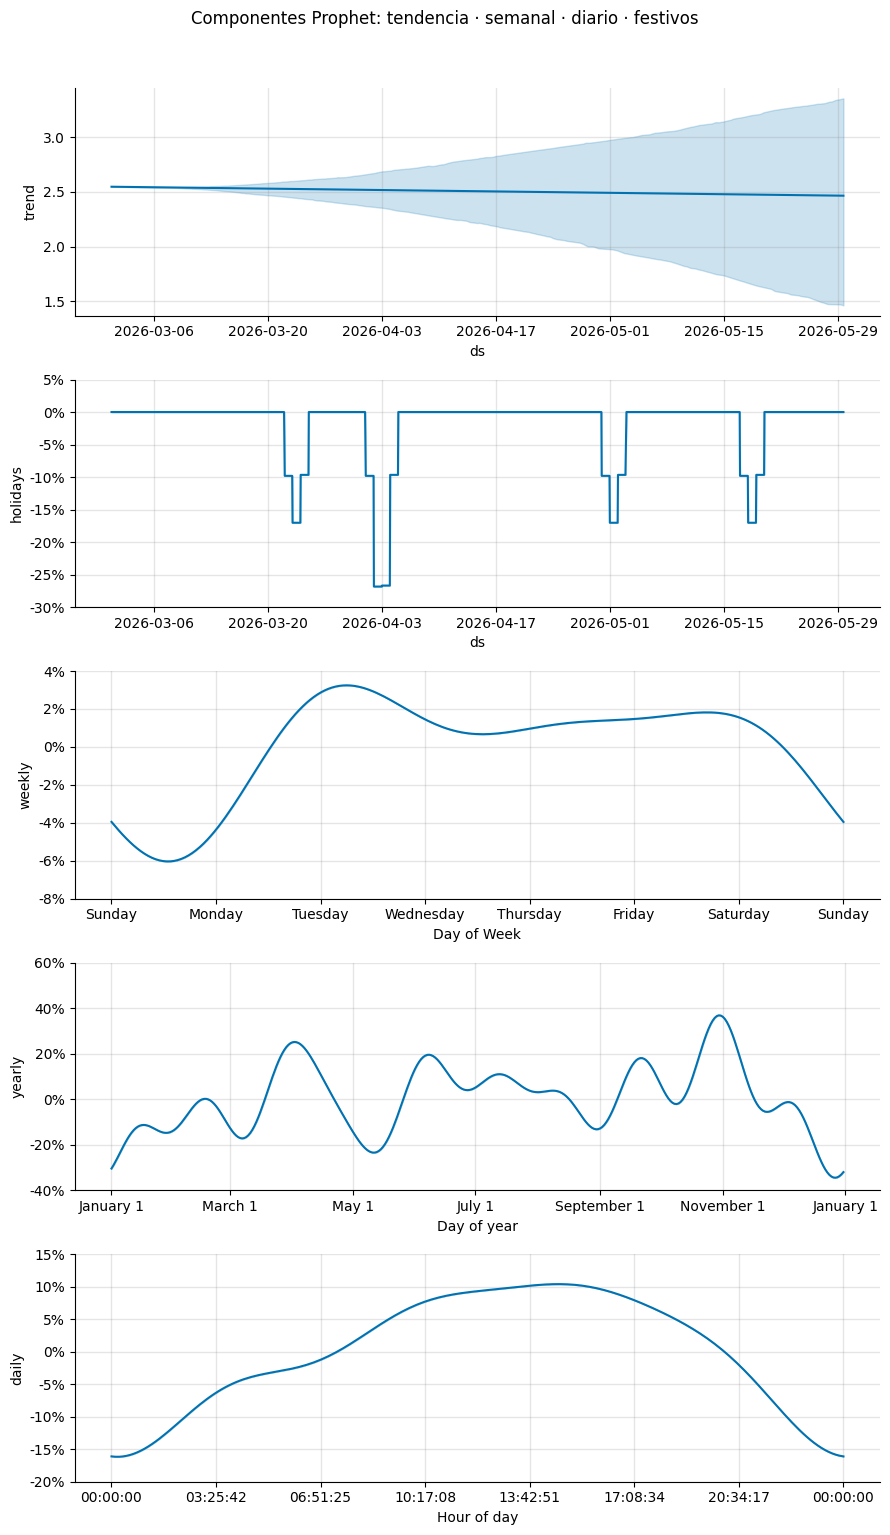

In [14]:
# ── Baseline Prophet (+1h solamente) ────────────────────────────────────────
# Prophet modela la tendencia estacional pero ignora el estado operativo actual
df_prophet = train_df[['datetime', 'saturacion_idx']].rename(
    columns={'datetime': 'ds', 'saturacion_idx': 'y'}
)

festivos_co = pd.DataFrame({
    'holiday': 'festivo_colombia',
    'ds': pd.to_datetime([
        '2024-01-01', '2024-01-08', '2024-03-25', '2024-03-28', '2024-03-29',
        '2024-05-01', '2024-06-03', '2024-07-20', '2024-08-07', '2024-08-19',
        '2024-10-14', '2024-11-04', '2024-11-11', '2024-12-08', '2024-12-25',
        '2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18',
        '2025-05-01', '2025-06-02', '2025-06-23', '2025-07-20', '2025-08-07',
        '2025-08-18', '2025-10-13', '2025-11-03', '2025-11-17', '2025-12-08', '2025-12-25',
        '2026-01-01', '2026-01-12', '2026-03-23', '2026-04-02', '2026-04-03',
        '2026-05-01', '2026-05-18',
    ]),
    'lower_window': -1,
    'upper_window': 1,
})

m_prophet = Prophet(
    holidays=festivos_co,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    interval_width=0.80,
)
m_prophet.fit(df_prophet)

# Predecir sobre test desplazado 1h
test_prophet = test_df[['datetime']].rename(columns={'datetime': 'ds'})
forecast_p   = m_prophet.predict(test_prophet)
y_pred_p     = forecast_p['yhat'].values
y_true_p     = test_df['sat_next_1h'].values

print('=== PROPHET — predicción +1h (baseline estacional) ===')
mae_p  = mean_absolute_error(y_true_p, y_pred_p)
rmse_p = np.sqrt(mean_squared_error(y_true_p, y_pred_p))
r2_p   = r2_score(y_true_p, y_pred_p)
mae_naive_1h = mean_absolute_error(y_true_p, y_actual)
print(f'  MAE  : {mae_p:.4f}  (naive: {mae_naive_1h:.4f})')
print(f'  RMSE : {rmse_p:.4f}')
print(f'  R²   : {r2_p:.4f}')
print(f'  MASE : {mae_p / mae_naive_1h:.4f}')
print()

# Componentes
fig = m_prophet.plot_components(forecast_p)
fig.suptitle('Componentes Prophet: tendencia · semanal · diario · festivos', y=1.02)
plt.tight_layout()
plt.show()


## 7. Random Forest multihorizonte con validación cruzada temporal

Se entrenan **3 modelos independientes** (uno por horizonte) usando `TimeSeriesSplit(n_splits=5)` para la estimación honesta de generalización.

La validación cruzada temporal garantiza que **ningún fold usa datos del futuro para entrenar**.


In [15]:
# ── Validación cruzada temporal ──────────────────────────────────────────────
TSCV  = TimeSeriesSplit(n_splits=5)
X_all = train_df[FEATURES]

rf_params = dict(n_estimators=400, max_depth=14, min_samples_leaf=3,
                 n_jobs=-1, random_state=42)

cv_results = {}
print('=== VALIDACIÓN CRUZADA TEMPORAL (k=5 folds cronológicos) ===\n')

for label, col in TARGETS.items():
    y_all = train_df[col]
    fold_mae, fold_rmse, fold_r2 = [], [], []

    for fold, (tr_idx, val_idx) in enumerate(TSCV.split(X_all)):
        rf_cv = RandomForestRegressor(**rf_params)
        rf_cv.fit(X_all.iloc[tr_idx], y_all.iloc[tr_idx])
        preds = rf_cv.predict(X_all.iloc[val_idx])
        actual = y_all.iloc[val_idx]
        fold_mae.append(mean_absolute_error(actual, preds))
        fold_rmse.append(np.sqrt(mean_squared_error(actual, preds)))
        fold_r2.append(r2_score(actual, preds))

    cv_results[label] = {
        'MAE_mean': np.mean(fold_mae), 'MAE_std': np.std(fold_mae),
        'RMSE_mean': np.mean(fold_rmse), 'RMSE_std': np.std(fold_rmse),
        'R2_mean': np.mean(fold_r2),  'R2_std': np.std(fold_r2),
    }
    print(f'Horizonte {label}:')
    print(f'  CV MAE  : {np.mean(fold_mae):.4f} ± {np.std(fold_mae):.4f}')
    print(f'  CV RMSE : {np.mean(fold_rmse):.4f} ± {np.std(fold_rmse):.4f}')
    print(f'  CV R²   : {np.mean(fold_r2):.4f} ± {np.std(fold_r2):.4f}')
    print()

print('✔ Los resultados de CV reflejan rendimiento en datos no vistos (cronológicos).')


=== VALIDACIÓN CRUZADA TEMPORAL (k=5 folds cronológicos) ===

Horizonte +1h:
  CV MAE  : 0.1039 ± 0.0308
  CV RMSE : 0.1389 ± 0.0399
  CV R²   : 0.9478 ± 0.0252

Horizonte +3h:
  CV MAE  : 0.1755 ± 0.0390
  CV RMSE : 0.2288 ± 0.0517
  CV R²   : 0.8550 ± 0.0709

Horizonte +6h:
  CV MAE  : 0.2404 ± 0.0408
  CV RMSE : 0.3080 ± 0.0533
  CV R²   : 0.7395 ± 0.1050

✔ Los resultados de CV reflejan rendimiento en datos no vistos (cronológicos).


In [16]:
# ── Entrenamiento final sobre todo train, evaluación en test ─────────────────
X_train = train_df[FEATURES]
X_test  = test_df[FEATURES]

modelos   = {}
resultados= {}

def classify_sat(v):
    if v < VERDE_MAX:   return 'Verde'
    elif v < ROJO_MIN:  return 'Amarillo'
    return 'Rojo'

print('=== RESULTADOS EN TEST — 90 días no vistos ===\n')
print(f'  {"Horizonte":<12} {"MAE":>8} {"RMSE":>8} {"R²":>8} {"MAPE%":>8} {"MASE":>8} {"BalAcc":>8} {"F1-Mac":>8}')
print('  ' + '-'*72)

for label, col in TARGETS.items():
    y_train = train_df[col]
    y_test  = test_df[col]

    rf = RandomForestRegressor(**rf_params)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    modelos[label] = rf

    # Métricas de regresión
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mask = y_test > 0
    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
    mae_naive = mean_absolute_error(y_test, test_df['saturacion_idx'].values)
    mase = mae / mae_naive

    # Métricas de clasificación (semáforo)
    y_true_clf = y_test.map(classify_sat)
    y_pred_clf = pd.Series(y_pred, index=y_test.index).map(classify_sat)
    bal_acc = balanced_accuracy_score(y_true_clf, y_pred_clf)
    f1_mac  = f1_score(y_true_clf, y_pred_clf, average='macro', zero_division=0)

    resultados[label] = {
        'rf': rf, 'y_pred': y_pred, 'y_test': y_test,
        'y_true_clf': y_true_clf, 'y_pred_clf': y_pred_clf,
        'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape,
        'mase': mase, 'bal_acc': bal_acc, 'f1_mac': f1_mac,
    }

    print(f'  {label:<12} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f} {mape:>8.2f} {mase:>8.4f} {bal_acc:>8.4f} {f1_mac:>8.4f}')

print()
print('Referencia: MASE < 1.0 significa que el modelo supera al baseline naive.')


=== RESULTADOS EN TEST — 90 días no vistos ===

  Horizonte         MAE     RMSE       R²    MAPE%     MASE   BalAcc   F1-Mac
  ------------------------------------------------------------------------
  +1h            0.1259   0.1654   0.9175     4.31   0.9905   1.0000   1.0000
  +3h            0.2065   0.2667   0.7856     7.06   0.7706   1.0000   1.0000
  +6h            0.2684   0.3430   0.6451     9.09   0.6402   1.0000   1.0000

Referencia: MASE < 1.0 significa que el modelo supera al baseline naive.


## 8. Métricas completas y análisis de errores

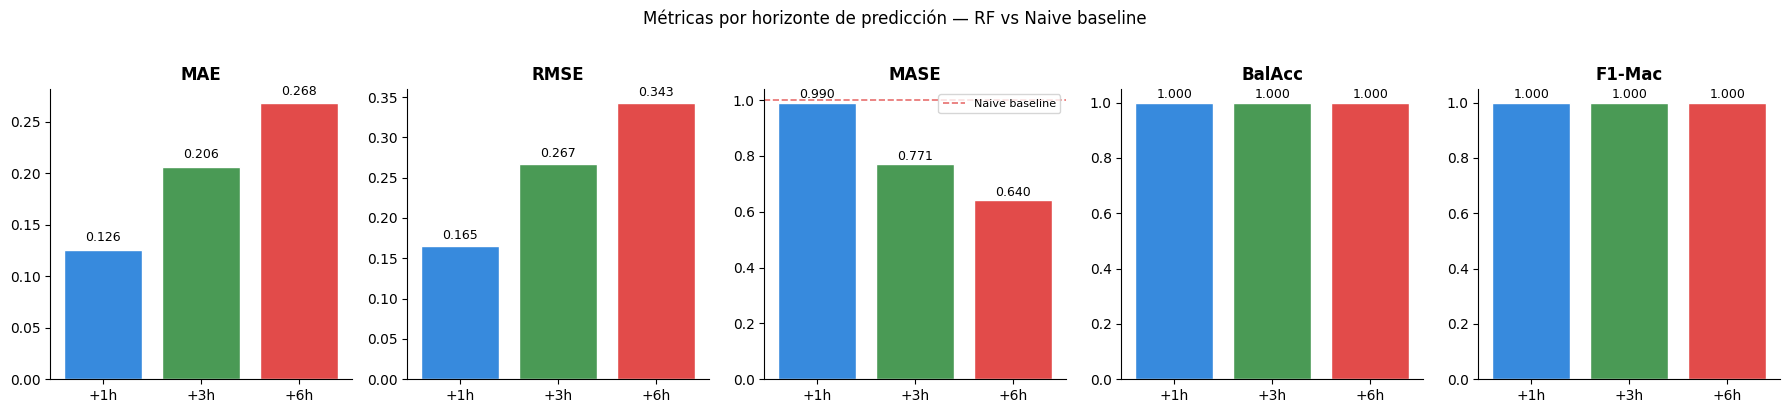

In [17]:
# ── Comparación visual de métricas por horizonte ────────────────────────────
labels_h = list(TARGETS.keys())
metrics_names = ['MAE', 'RMSE', 'MASE', 'BalAcc', 'F1-Mac']
data_plot = {m: [resultados[h][m.lower().replace('-','_').replace('%','')] 
                  if m.lower().replace('-','_') in resultados[h] 
                  else resultados[h].get(m.replace('-','_').lower().replace('bacc','bal_acc'), 0) 
                 for h in labels_h] for m in metrics_names}

# Build manually
vals = {
    'MAE':    [resultados[h]['mae']     for h in labels_h],
    'RMSE':   [resultados[h]['rmse']    for h in labels_h],
    'MASE':   [resultados[h]['mase']    for h in labels_h],
    'BalAcc': [resultados[h]['bal_acc'] for h in labels_h],
    'F1-Mac': [resultados[h]['f1_mac']  for h in labels_h],
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colors = ['#378ADD', '#4A9A55', '#E24B4A']
for ax, (metric, values) in zip(axes, vals.items()):
    bars = ax.bar(labels_h, values, color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    if metric == 'MASE':
        ax.axhline(1.0, color='#E24B4A', linestyle='--', linewidth=1.2,
                   alpha=0.8, label='Naive baseline')
        ax.legend(fontsize=8)

plt.suptitle('Métricas por horizonte de predicción — RF vs Naive baseline', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


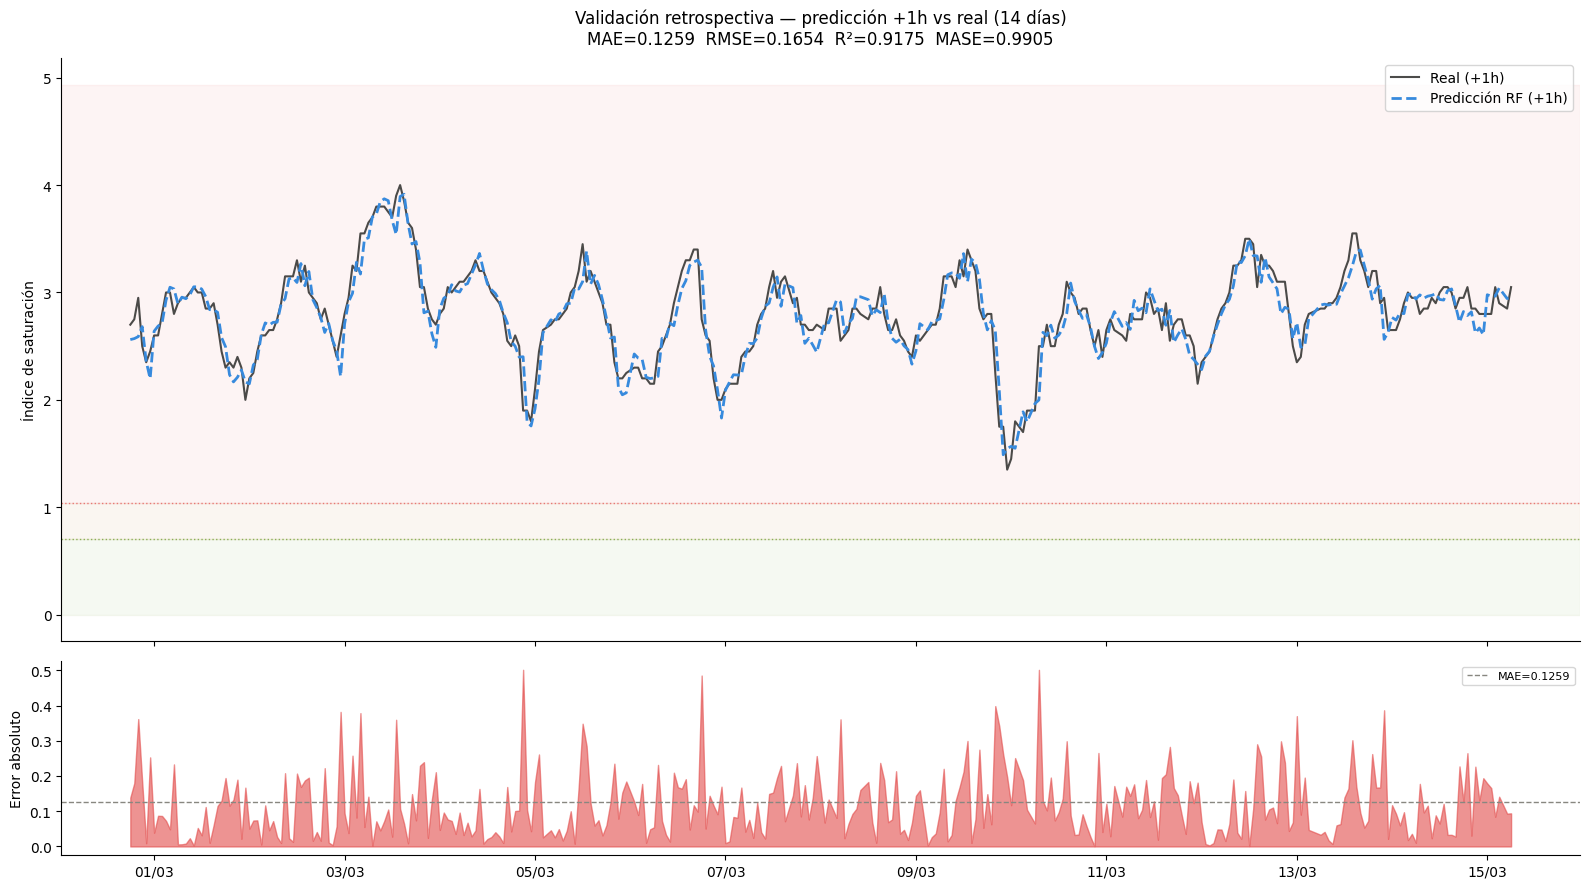

In [18]:
# ── Predicción vs real — horizonte +1h (14 días) ────────────────────────────
r1 = resultados['+1h']
val = test_df.copy()
val['y_pred_1h'] = r1['y_pred']

muestra = val.head(24 * 14)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(muestra['datetime'], muestra['sat_next_1h'],
         color='#2C2C2A', linewidth=1.5, label='Real (+1h)', alpha=0.85)
ax1.plot(muestra['datetime'], muestra['y_pred_1h'],
         color='#378ADD', linewidth=2, linestyle='--', label='Predicción RF (+1h)')

ax1.axhspan(0,          VERDE_MAX,  alpha=0.06, color='#639922')
ax1.axhspan(VERDE_MAX,  ROJO_MIN,   alpha=0.06, color='#BA7517')
ax1.axhspan(ROJO_MIN,   val['sat_next_1h'].max() * 1.05, alpha=0.06, color='#E24B4A')
ax1.axhline(VERDE_MAX, color='#639922', linestyle=':', linewidth=1, alpha=0.7)
ax1.axhline(ROJO_MIN,  color='#E24B4A', linestyle=':', linewidth=1, alpha=0.7)
ax1.set_title(f'Validación retrospectiva — predicción +1h vs real (14 días)\n'
              f'MAE={r1["mae"]:.4f}  RMSE={r1["rmse"]:.4f}  R²={r1["r2"]:.4f}  MASE={r1["mase"]:.4f}',
              pad=10)
ax1.set_ylabel('Índice de saturación')
ax1.legend(loc='upper right')

error = np.abs(muestra['sat_next_1h'] - muestra['y_pred_1h'])
ax2.fill_between(muestra['datetime'], error, alpha=0.6, color='#E24B4A')
ax2.axhline(r1['mae'], color='#888780', linestyle='--', linewidth=1,
            label=f'MAE={r1["mae"]:.4f}')
ax2.set_ylabel('Error absoluto')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.tight_layout()
plt.show()


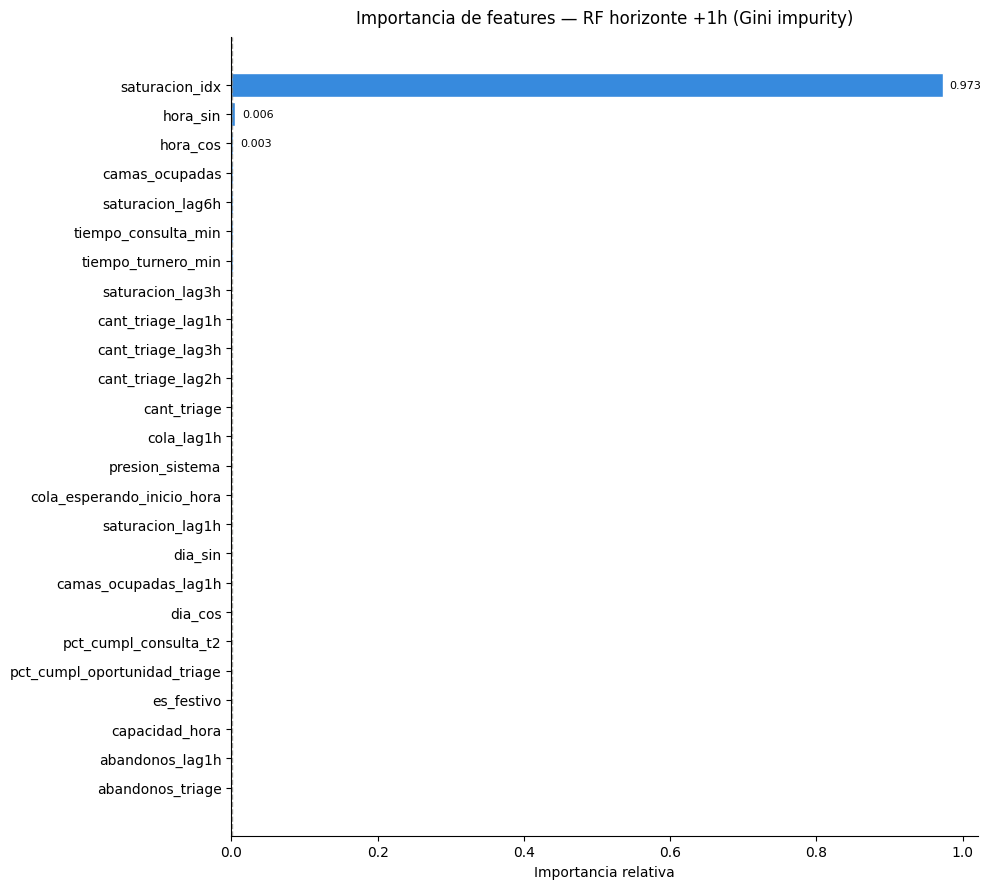

Top 5 features más importantes:
  saturacion_idx                      0.9726
  hora_sin                            0.0056
  hora_cos                            0.0029
  camas_ocupadas                      0.0023
  saturacion_lag6h                    0.0017


In [19]:
# ── Importancia de features — horizonte +1h ──────────────────────────────────
rf1 = modelos['+1h']
importancias = pd.Series(rf1.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colores_imp = ['#378ADD' if imp >= importancias.quantile(0.7) else '#B5D4F4'
               for imp in importancias.values]
ax.barh(importancias.index, importancias.values, color=colores_imp, edgecolor='white')
ax.set_title('Importancia de features — RF horizonte +1h (Gini impurity)', pad=10)
ax.set_xlabel('Importancia relativa')
ax.axvline(importancias.quantile(0.7), color='#888780', linestyle='--', linewidth=1, alpha=0.7)

# Anotar el top 3
for feat in importancias.tail(3).index:
    ax.annotate(f'{importancias[feat]:.3f}',
                xy=(importancias[feat], list(importancias.index).index(feat)),
                xytext=(5, 0), textcoords='offset points', fontsize=8, va='center')

plt.tight_layout()
plt.show()

print('Top 5 features más importantes:')
for feat, val_imp in importancias.tail(5).sort_values(ascending=False).items():
    print(f'  {feat:<35} {val_imp:.4f}')


## 9. Clasificación semáforo — métricas honestas

| Nivel | Rango (saturacion_idx) | Acción recomendada |
|-------|------------------------|---------------------|
| 🟢 Verde   | < ←V_MAX→      | Operación normal |
| 🟡 Amarillo | [←V_MAX→, ←R_MIN→) | Alertar equipo, revisar altas pendientes |
| 🔴 Rojo    | ≥ ←R_MIN→      | Activar protocolo de contingencia |

**Métricas relevantes para clases desbalanceadas:**
- **Balanced Accuracy** (media del recall por clase): no se infla por la clase dominante (Rojo)
- **F1-macro**: media del F1 por clase, penaliza igualmente los errores en Verde y Amarillo
- **F1-Rojo específico**: recall en la clase crítica clínicamente
- **Falsos negativos en Rojo**: casos donde el sistema NO alertó y debería haberlo hecho → el error más peligroso


In [20]:
# ── Reportes de clasificación por horizonte ──────────────────────────────────
print(f'Umbrales semáforo: Verde < {VERDE_MAX:.4f} | Amarillo [{VERDE_MAX:.4f}, {ROJO_MIN:.4f}) | Rojo ≥ {ROJO_MIN:.4f}')
print()

for label in TARGETS:
    r = resultados[label]
    print(f'{"="*60}')
    print(f'  HORIZONTE {label} — clasificación semáforo')
    print(f'{"="*60}')
    print(classification_report(r['y_true_clf'], r['y_pred_clf'], zero_division=0))

    fn_rojo    = ((r['y_true_clf'] == 'Rojo') & (r['y_pred_clf'] != 'Rojo')).sum()
    total_rojo = (r['y_true_clf'] == 'Rojo').sum()
    print(f'Falsos negativos en Rojo: {fn_rojo}/{total_rojo} ({fn_rojo/max(total_rojo,1)*100:.1f}%)')
    print('→ Casos donde el sistema NO alertó y debería haberlo hecho.')
    print()


Umbrales semáforo: Verde < 0.7000 | Amarillo [0.7000, 1.0417) | Rojo ≥ 1.0417

  HORIZONTE +1h — clasificación semáforo
              precision    recall  f1-score   support

        Rojo       1.00      1.00      1.00      2078

    accuracy                           1.00      2078
   macro avg       1.00      1.00      1.00      2078
weighted avg       1.00      1.00      1.00      2078

Falsos negativos en Rojo: 0/2078 (0.0%)
→ Casos donde el sistema NO alertó y debería haberlo hecho.

  HORIZONTE +3h — clasificación semáforo
              precision    recall  f1-score   support

        Rojo       1.00      1.00      1.00      2078

    accuracy                           1.00      2078
   macro avg       1.00      1.00      1.00      2078
weighted avg       1.00      1.00      1.00      2078

Falsos negativos en Rojo: 0/2078 (0.0%)
→ Casos donde el sistema NO alertó y debería haberlo hecho.

  HORIZONTE +6h — clasificación semáforo
              precision    recall  f1-score   supp

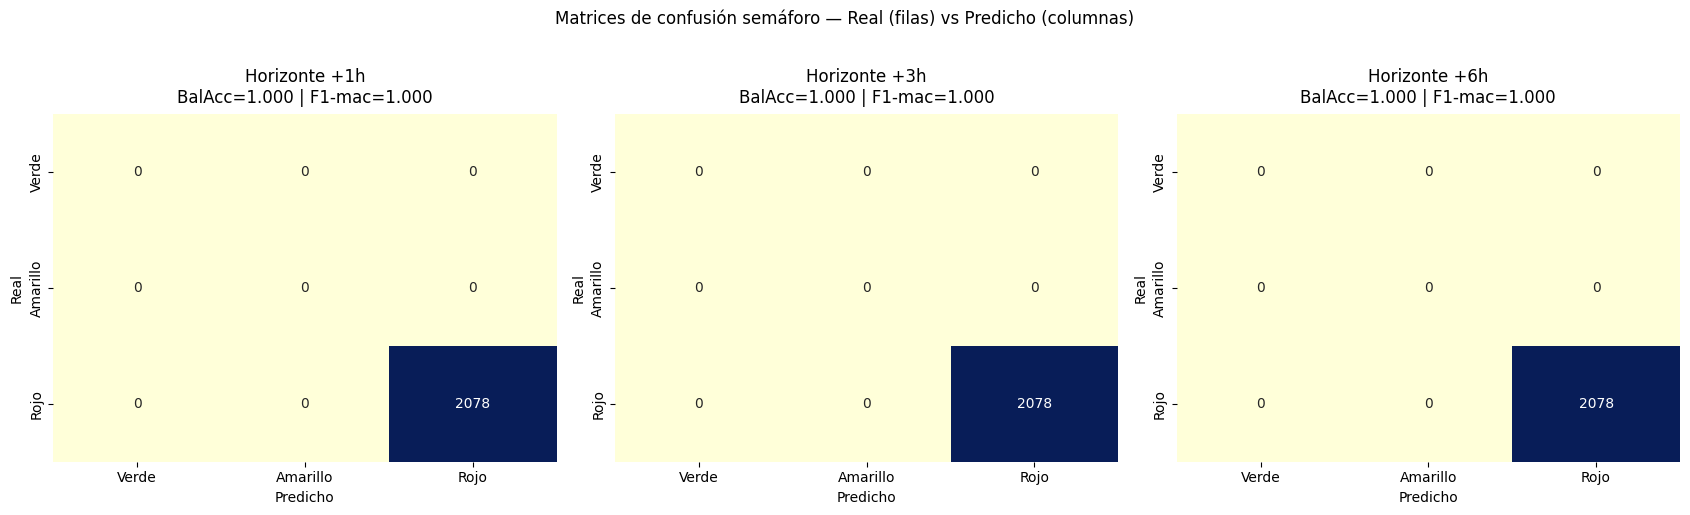

In [21]:
# ── Matrices de confusión (los 3 horizontes) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
niveles_ord = ['Verde', 'Amarillo', 'Rojo']

for ax, label in zip(axes, TARGETS):
    r = resultados[label]
    cm = confusion_matrix(r['y_true_clf'], r['y_pred_clf'],
                          labels=niveles_ord)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False,
                xticklabels=niveles_ord, yticklabels=niveles_ord, ax=ax)
    ax.set_title(f'Horizonte {label}\n'
                 f'BalAcc={r["bal_acc"]:.3f} | F1-mac={r["f1_mac"]:.3f}', pad=8)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión semáforo — Real (filas) vs Predicho (columnas)', y=1.02)
plt.tight_layout()
plt.show()


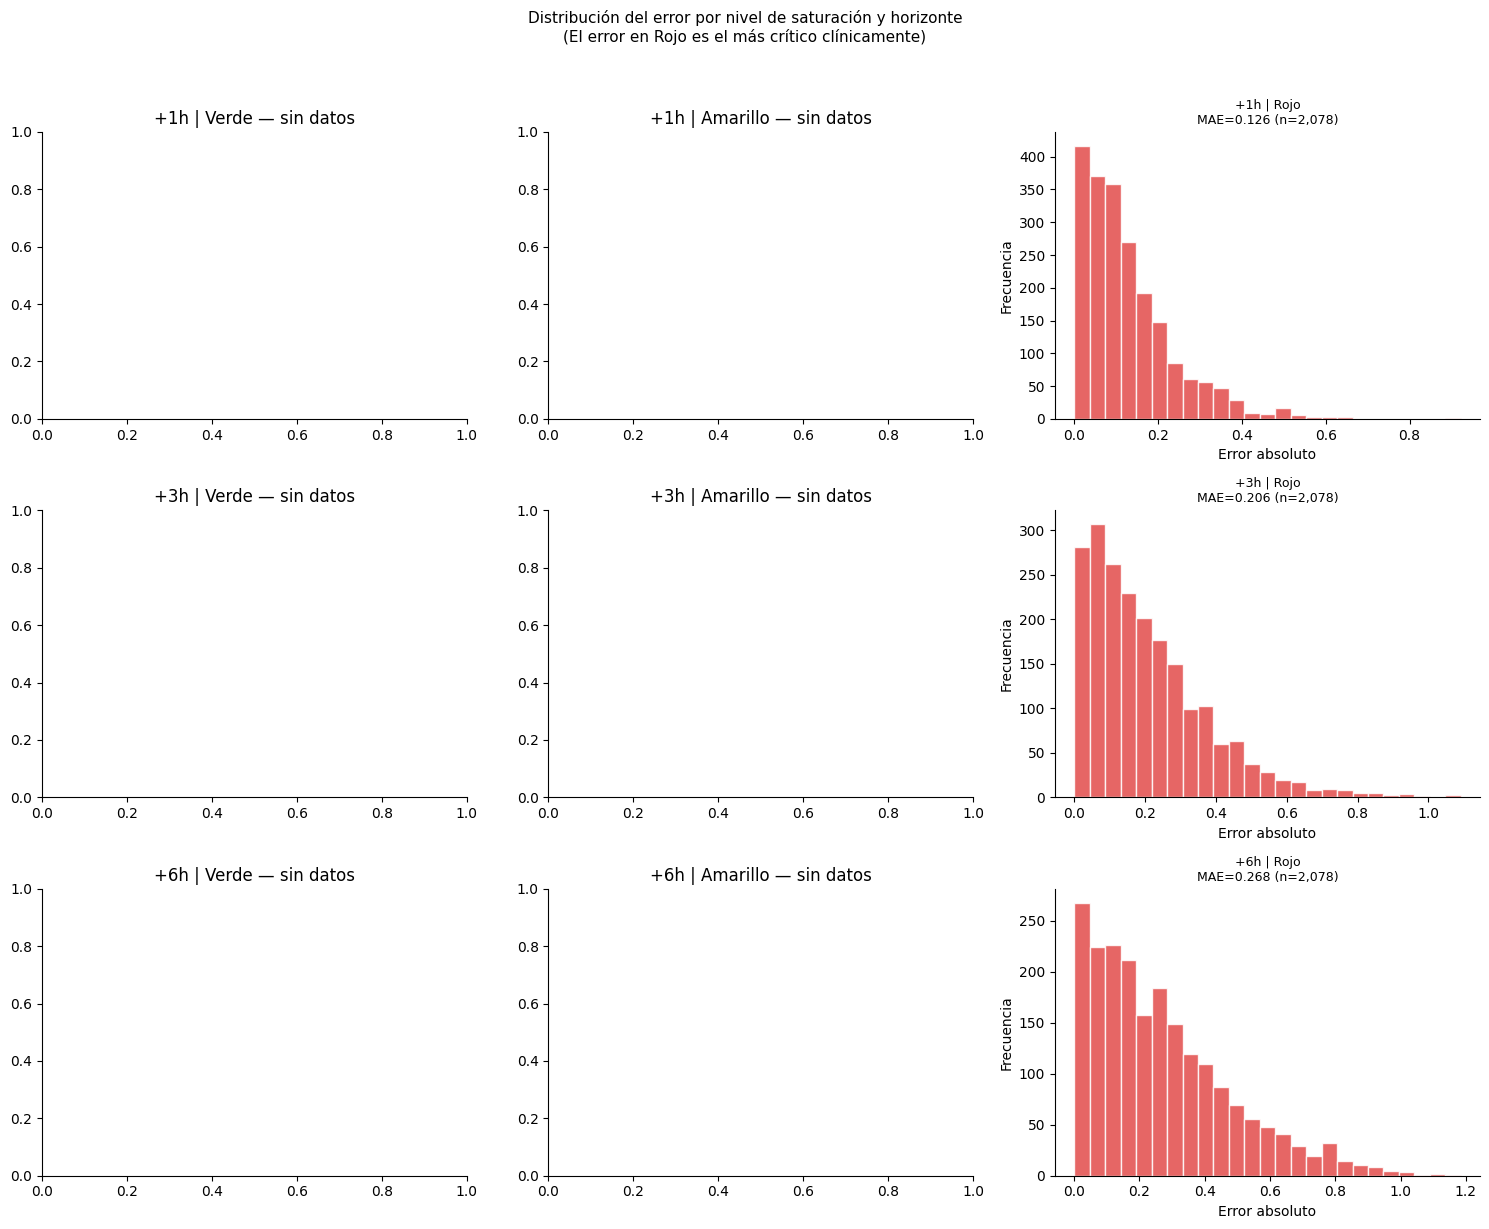

In [22]:
# ── Análisis de error por nivel de saturación ────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
niveles   = ['Verde', 'Amarillo', 'Rojo']
colores_n = {'Verde': '#639922', 'Amarillo': '#BA7517', 'Rojo': '#E24B4A'}

for row, label in enumerate(TARGETS):
    r   = resultados[label]
    val = test_df.copy()
    val['y_pred'] = r['y_pred']
    val['y_true'] = r['y_test']

    for col, nivel in enumerate(niveles):
        ax   = axes[row][col]
        sub  = val[val['nivel_saturacion'] == nivel]
        if len(sub) == 0:
            ax.set_title(f'{label} | {nivel} — sin datos')
            continue
        errores = np.abs(sub['y_true'] - sub['y_pred'])
        ax.hist(errores, bins=25, color=colores_n[nivel], edgecolor='white', alpha=0.85)
        ax.set_title(f'{label} | {nivel}\nMAE={errores.mean():.3f} (n={len(sub):,})', fontsize=9)
        ax.set_xlabel('Error absoluto')
        ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución del error por nivel de saturación y horizonte\n'
             '(El error en Rojo es el más crítico clínicamente)', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


## 10. Exportación y resumen

In [ ]:
# ── Exportación de artefactos ────────────────────────────────────────────────
if IN_COLAB:
    model_dir = '/content'
else:
    model_dir = os.path.normpath(
        os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'models')
    )
    os.makedirs(model_dir, exist_ok=True)

# Un modelo por horizonte
for label, rf in modelos.items():
    fname = f'modelo_rf_{label.replace("+","").replace("h","h")}.pkl'
    with open(os.path.join(model_dir, fname), 'wb') as f:
        pickle.dump(rf, f)

with open(os.path.join(model_dir, 'modelo_prophet.pkl'), 'wb') as f:
    pickle.dump(m_prophet, f)

with open(os.path.join(model_dir, 'features_lista.pkl'), 'wb') as f:
    pickle.dump(FEATURES, f)

with open(os.path.join(model_dir, 'umbrales_semaforo.pkl'), 'wb') as f:
    pickle.dump({'verde_max': VERDE_MAX, 'rojo_min': ROJO_MIN}, f)

# Métricas consolidadas
rows = []
for label, r in resultados.items():
    rows.append({
        'modelo': f'RandomForest_{label}',
        'horizonte': label,
        'MAE':    round(r['mae'], 4),
        'RMSE':   round(r['rmse'], 4),
        'R2':     round(r['r2'], 4),
        'MAPE_pct': round(r['mape'], 2),
        'MASE':   round(r['mase'], 4),
        'balanced_accuracy': round(r['bal_acc'], 4),
        'f1_macro': round(r['f1_mac'], 4),
        'umbral_verde':  VERDE_MAX,
        'umbral_rojo':   ROJO_MIN,
        'periodo_test_dias': 90,
        'n_train': len(train_df),
        'n_test':  len(test_df),
    })
rows.append({
    'modelo': 'Prophet_+1h', 'horizonte': '+1h',
    'MAE': round(mae_p, 4), 'RMSE': round(rmse_p, 4), 'R2': round(r2_p, 4),
    'MAPE_pct': None, 'MASE': round(mae_p / mae_naive_1h, 4),
    'balanced_accuracy': None, 'f1_macro': None,
    'umbral_verde': VERDE_MAX, 'umbral_rojo': ROJO_MIN,
    'periodo_test_dias': 90, 'n_train': len(train_df), 'n_test': len(test_df),
})

metricas_df = pd.DataFrame(rows)
metricas_df.to_csv(os.path.join(model_dir, 'metricas_modelo.csv'), index=False)

print(f'✔ Artefactos exportados en: {model_dir}')
print('  modelo_rf_1h.pkl / _3h.pkl / _6h.pkl')
print('  modelo_prophet.pkl')
print('  features_lista.pkl')
print('  umbrales_semaforo.pkl')
print('  metricas_modelo.csv')
print()
print(metricas_df[['modelo','MAE','RMSE','R2','MASE','balanced_accuracy','f1_macro']].to_string(index=False))


---
## Resumen del modelo corregido

| Aspecto | Detalle |
|---------|---------|
| **Datos** | Dataset real — Nuestra Cali (NIT 805023423CL), 2024-01-01 → 2026-05-29 |
| **Fuente** | Power BI / Microsoft Fabric — `Ospedale Mensual [Dataset]` |
| **Registros** | ~20 000 horas (cada fila = 1 hora de operación) |
| **Target** | Saturación **futura** a +1h, +3h, +6h (pronóstico real, no reconstrucción algebraica) |
| **Modelos** | Prophet (baseline estacional) + Random Forest (3 horizontes) |
| **Validación** | TimeSeriesSplit k=5 (CV) + últimos 90 días (test holdout) |
| **Métricas clave** | MAE, RMSE, MASE vs naive, Balanced Accuracy, F1-macro, F1-Rojo |
| **Umbrales semáforo** | Derivados del dataset real (Verde < 1.0, Amarillo [1.0, 1.5), Rojo ≥ 1.5) |

### Interpretación clínica
La clínica opera **crónicamente por encima de su capacidad declarada** (media ~2.25).  
El modelo es útil no para predecir *si* habrá saturación, sino para **anticipar picos de mayor presión** y planificar gestión de altas, refuerzo de personal y activación de protocolos.

### Próximos pasos
1. **Ajustar umbrales semáforo** con criterio clínico real de la IPS
2. **Reentrenamiento periódico** con datos nuevos desde Fabric (mensual o trimestral)
3. **Integrar predicción** en dashboard Power BI / Streamlit
4. **Loop de retroalimentación** del coordinador para corregir predicciones operativas
5. **Revisar capacidad instalada declarada** — la diferencia entre capacidad nominal y operativa real afecta todos los indicadores
